
>>> Device: cuda
>>> Scenario: uniform_should_win
>>> Pricing: uniform

RUN 1/3 | players=8 | demand_units=2

>>> Pretraining truthful bidding (bid = cost)...
Pretrain step    0/200 | loss=0.08116366
Pretrain step   50/200 | loss=0.00001493
Pretrain step  100/200 | loss=0.00000196
Pretrain step  150/200 | loss=0.00000078
Pretrain step  199/200 | loss=0.00000040
[Epoch    0] BuyerCost=0.557517 | SuppProfit=0.001659 | AvgBid=0.299985 | AvgMarkup=0.000000 | AcceptedBid=0.272122 | Pay=0.278759 | Clear=0.278759 | GradNorm=3.249859e-02
[Epoch   50] BuyerCost=0.557335 | SuppProfit=0.001616 | AvgBid=0.299894 | AvgMarkup=0.000000 | AcceptedBid=0.272205 | Pay=0.278668 | Clear=0.278668 | GradNorm=1.420946e-02
[Epoch  100] BuyerCost=0.557976 | SuppProfit=0.001639 | AvgBid=0.300068 | AvgMarkup=0.000031 | AcceptedBid=0.272431 | Pay=0.278988 | Clear=0.278988 | GradNorm=1.238926e-02
[Epoch  150] BuyerCost=0.558056 | SuppProfit=0.001667 | AvgBid=0.300542 | AvgMarkup=0.000390 | AcceptedBid=0.272362 | P

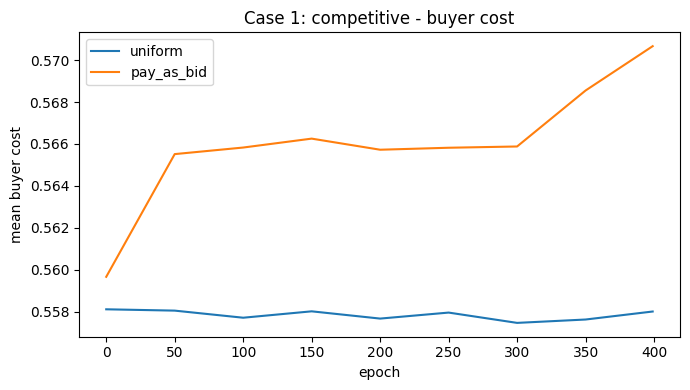

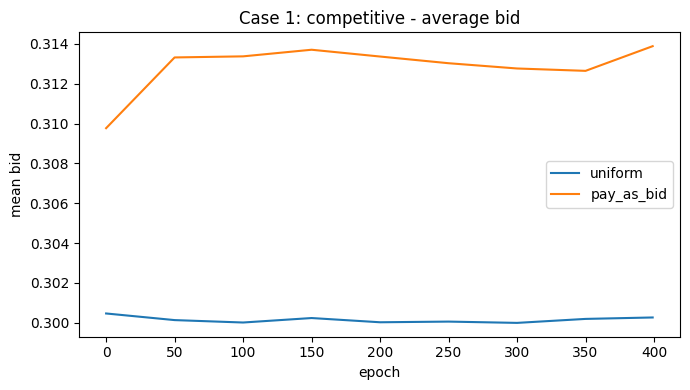

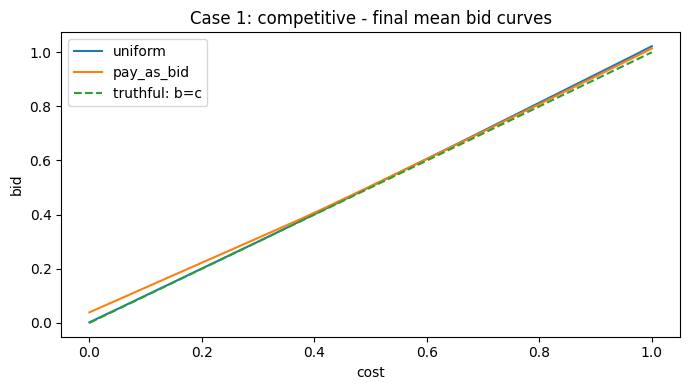


>>> Device: cuda
>>> Scenario: pab_should_win
>>> Pricing: uniform

RUN 1/3 | players=4 | demand_units=3

>>> Pretraining truthful bidding (bid = cost)...
Pretrain step    0/200 | loss=0.00000000
Pretrain step   50/200 | loss=0.00000000
Pretrain step  100/200 | loss=0.00000000
Pretrain step  150/200 | loss=0.00000000
Pretrain step  199/200 | loss=0.00000000
[Epoch    0] BuyerCost=1.703754 | SuppProfit=0.103569 | AvgBid=0.504041 | AvgMarkup=0.004476 | AcceptedBid=0.434508 | Pay=0.567918 | Clear=0.567918 | GradNorm=1.629483e-01
[Epoch   50] BuyerCost=2.036474 | SuppProfit=0.179413 | AvgBid=0.603239 | AvgMarkup=0.103764 | AcceptedBid=0.526652 | Pay=0.678825 | Clear=0.678825 | GradNorm=4.298607e-02
[Epoch  100] BuyerCost=2.023792 | SuppProfit=0.177476 | AvgBid=0.597952 | AvgMarkup=0.098074 | AcceptedBid=0.525354 | Pay=0.674597 | Clear=0.674598 | GradNorm=2.914155e-02
[Epoch  150] BuyerCost=1.997874 | SuppProfit=0.172448 | AvgBid=0.590578 | AvgMarkup=0.091650 | AcceptedBid=0.524843 | Pay=0

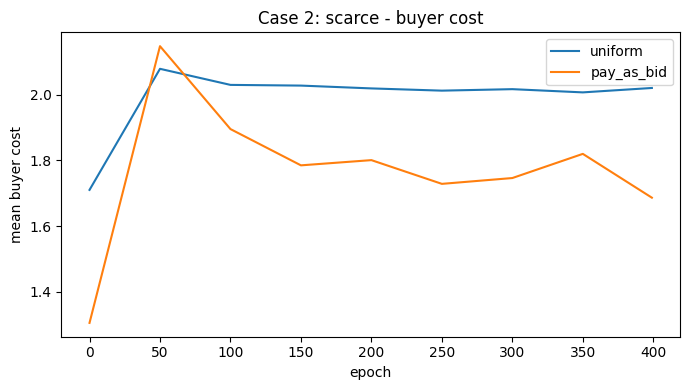

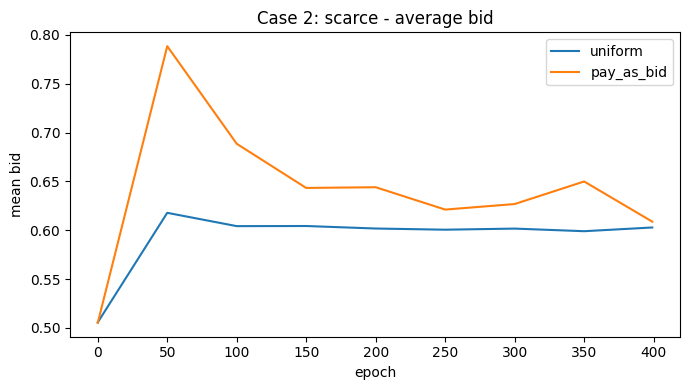

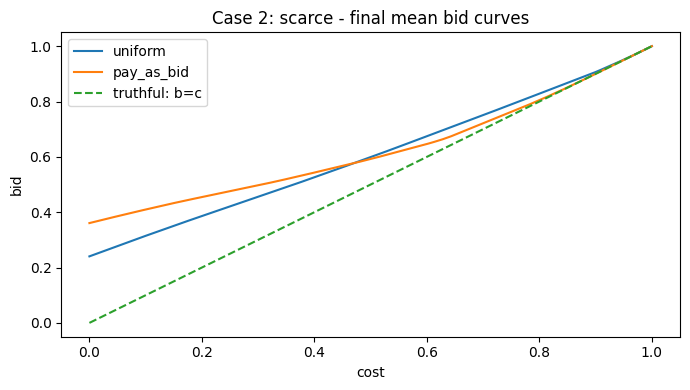

In [ ]:
import copy
import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ============================================================
# 0. SEED
# ============================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ============================================================
# 1. MULTI-UNIT PROCUREMENT SAMPLER
#    Scenario A: competitive  -> uniform should win
#    Scenario B: scarce       -> pay-as-bid should win
# ============================================================
class ProcurementSampler:
    def __init__(self, scenario_name: str):
        self.scenario_name = scenario_name

        if scenario_name == "uniform_should_win":
            # Mucha competencia, baja demanda, costos parecidos
            self.n_players = 8
            self.demand_units = 2
            self.beta_a = 8.0
            self.beta_b = 8.0
            self.cost_low = 0.20
            self.cost_high = 0.40

        elif scenario_name == "pab_should_win":
            # Poca competencia, demanda alta, costos más dispersos
            self.n_players = 4
            self.demand_units = 3
            self.beta_a = 2.0
            self.beta_b = 2.0
            self.cost_low = 0.05
            self.cost_high = 0.95

        else:
            raise ValueError(f"Unknown scenario_name: {scenario_name}")

    def sample(self, batch_size):
        # Costs ~ scaled Beta(a,b)
        dist = torch.distributions.Beta(self.beta_a, self.beta_b)
        x = dist.sample((batch_size, self.n_players, 1))
        c = self.cost_low + (self.cost_high - self.cost_low) * x
        o = c.clone()   # observation = cost
        return c, o


# ============================================================
# 2. BIDDER NET
#    bid = cost + nonnegative markup
# ============================================================
class BidderNet(nn.Module):
    def __init__(self, hidden=10):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, hidden),
            nn.SELU(),
            nn.Linear(hidden, hidden),
            nn.SELU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        markup = torch.relu(self.layers(x))
        return x + markup


# ============================================================
# 3. PRETRAINING
#    pushes bids close to truthful: bid = cost
# ============================================================
def pretrain_truthful(policies, sampler, device, steps=200, batch_size=4096, lr=1e-2):
    optims = [torch.optim.SGD(pol.parameters(), lr=lr) for pol in policies]

    print("\n>>> Pretraining truthful bidding (bid = cost)...")
    for step in range(steps):
        costs, obs = sampler.sample(batch_size)
        costs, obs = costs.to(device), obs.to(device)

        for i, pol in enumerate(policies):
            optims[i].zero_grad()
            pred = pol(obs[:, i])
            target = costs[:, i]
            loss = ((pred - target) ** 2).mean()
            loss.backward()
            optims[i].step()

        if step % 50 == 0 or step == steps - 1:
            print(f"Pretrain step {step:4d}/{steps} | loss={loss.item():.8f}")


# ============================================================
# 4. PROCUREMENT OUTCOME
#    Multi-unit reverse auction:
#    accept Q lowest bids
#
#    uniform: all accepted are paid the marginal accepted bid
#    pay_as_bid: each accepted is paid own bid
# ============================================================
def procurement_outcome(bids, costs, demand_units, pricing):
    """
    bids, costs: shape (batch_size, n_players)
    demand_units: integer number of accepted suppliers
    pricing: "uniform" or "pay_as_bid"

    Returns:
        accepted_mask : (B, N) bool
        payments      : (B, N)
        profits       : (B, N)
        buyer_cost    : (B,)
        clearing_bid  : (B, 1)
    """
    B, N = bids.shape
    assert 1 <= demand_units <= N

    topk = torch.topk(bids, k=demand_units, dim=1, largest=False)
    accepted_idx = topk.indices                      # (B, Q)
    accepted_bids_sorted = topk.values              # (B, Q)
    clearing_bid = accepted_bids_sorted[:, -1].unsqueeze(1)   # Q-th lowest

    accepted_mask = torch.zeros_like(bids, dtype=torch.bool)
    accepted_mask.scatter_(1, accepted_idx, True)

    if pricing == "uniform":
        payments = torch.where(
            accepted_mask,
            clearing_bid.expand_as(bids),
            torch.zeros_like(bids)
        )
    elif pricing == "pay_as_bid":
        payments = torch.where(
            accepted_mask,
            bids,
            torch.zeros_like(bids)
        )
    else:
        raise ValueError(f"Unknown pricing: {pricing}")

    profits = torch.where(
        accepted_mask,
        payments - costs,
        torch.zeros_like(bids)
    )

    buyer_cost = payments.sum(dim=1)
    return accepted_mask, payments, profits, buyer_cost, clearing_bid


# ============================================================
# 5. FLATTEN / LOAD PARAMS
# ============================================================
def flatten_params(model):
    return torch.cat([p.data.flatten() for p in model.parameters()])


def load_flat_params(model, theta_vec):
    offset = 0
    for p in model.parameters():
        size = p.numel()
        p.data.copy_(theta_vec[offset:offset + size].view_as(p))
        offset += size


# ============================================================
# 6. EVALUATION
# ============================================================
@torch.no_grad()
def evaluate_policies(policies, sampler, device, pricing, eval_batch_size=8192, grid_n=200):
    n_players = len(policies)
    demand_units = sampler.demand_units

    costs, obs = sampler.sample(eval_batch_size)
    costs, obs = costs.to(device), obs.to(device)

    bids = torch.cat([policies[i](obs[:, i]) for i in range(n_players)], dim=1)
    costs2 = costs.squeeze(-1)

    accepted_mask, payments, profits, buyer_cost, clearing_bid = procurement_outcome(
        bids=bids,
        costs=costs2,
        demand_units=demand_units,
        pricing=pricing
    )

    avg_bid = bids.mean().item()
    avg_markup = (bids - costs2).mean().item()

    accepted_float = accepted_mask.float()
    accepted_count = accepted_float.sum().item()

    if accepted_count > 0:
        avg_accepted_bid = (bids * accepted_float).sum().item() / accepted_count
        avg_accepted_markup = ((bids - costs2) * accepted_float).sum().item() / accepted_count
        avg_payment = (payments * accepted_float).sum().item() / accepted_count
    else:
        avg_accepted_bid = float("nan")
        avg_accepted_markup = float("nan")
        avg_payment = float("nan")

    mean_buyer_cost = buyer_cost.mean().item()
    mean_supplier_profit = profits.mean().item()
    mean_clearing_bid = clearing_bid.mean().item()

    # Bid curves
    grid = torch.linspace(0, 1, grid_n, device=device).view(grid_n, 1)
    curves = []
    for i in range(n_players):
        curves.append(policies[i](grid).cpu().numpy().squeeze())
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)

    return {
        "avg_bid": avg_bid,
        "avg_markup": avg_markup,
        "avg_accepted_bid": avg_accepted_bid,
        "avg_accepted_markup": avg_accepted_markup,
        "avg_payment": avg_payment,
        "buyer_cost": mean_buyer_cost,
        "supplier_profit": mean_supplier_profit,
        "clearing_bid": mean_clearing_bid,
        "curves_all": curves,
        "curve_mean": mean_curve,
        "grid": grid.cpu().numpy().squeeze(),
    }


# ============================================================
# 7. TRAIN NPGA FOR MULTI-UNIT PROCUREMENT
# ============================================================
def train_npga_procurement(
    scenario_name="uniform_should_win",
    pricing="uniform",
    n_epochs=400,
    pretrain_iters=200,
    batch_size=4096,
    pop=32,
    lr=3e-3,
    sigma=1e-2,
    hidden=10,
    eval_frequency=50,
    n_runs=3,
    eval_batch_size=8192,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("\n>>> Device:", device)
    print(">>> Scenario:", scenario_name)
    print(">>> Pricing:", pricing)

    all_results = []

    for run in range(n_runs):
        seed = 1000 + run
        set_seed(seed)

        sampler = ProcurementSampler(scenario_name)
        n_players = sampler.n_players
        demand_units = sampler.demand_units

        print("\n" + "=" * 60)
        print(f"RUN {run+1}/{n_runs} | players={n_players} | demand_units={demand_units}")
        print("=" * 60)

        policies = [BidderNet(hidden=hidden).to(device) for _ in range(n_players)]
        optims = [torch.optim.Adam(pol.parameters(), lr=lr) for pol in policies]

        pretrain_truthful(
            policies=policies,
            sampler=sampler,
            device=device,
            steps=pretrain_iters,
            batch_size=batch_size,
            lr=1e-2
        )

        results = {
            "epoch": [],
            "buyer_cost": [],
            "supplier_profit": [],
            "avg_bid": [],
            "avg_markup": [],
            "avg_accepted_bid": [],
            "avg_accepted_markup": [],
            "avg_payment": [],
            "clearing_bid": [],
            "grad_norm": [],
            "curve_mean": [],
            "curves_all": [],
        }

        for epoch in range(n_epochs):
            costs, obs = sampler.sample(batch_size)
            costs, obs = costs.to(device), obs.to(device)

            grad_norms_epoch = []

            for i in range(n_players):
                theta = flatten_params(policies[i])
                d = theta.numel()
                grad_vec = torch.zeros_like(theta, device=device)

                for _ in range(pop):
                    eps = torch.randn(d, device=device)

                    # + perturbation
                    pert_plus = BidderNet(hidden=hidden).to(device)
                    load_flat_params(pert_plus, theta + sigma * eps)

                    with torch.no_grad():
                        bids_plus = []
                        for j in range(n_players):
                            if j == i:
                                bids_plus.append(pert_plus(obs[:, j]))
                            else:
                                bids_plus.append(policies[j](obs[:, j]))
                        bids_plus = torch.cat(bids_plus, dim=1)

                        _, _, profits_plus, _, _ = procurement_outcome(
                            bids=bids_plus,
                            costs=costs.squeeze(-1),
                            demand_units=demand_units,
                            pricing=pricing
                        )
                        u_plus = profits_plus[:, i].mean()

                    # - perturbation
                    pert_minus = BidderNet(hidden=hidden).to(device)
                    load_flat_params(pert_minus, theta - sigma * eps)

                    with torch.no_grad():
                        bids_minus = []
                        for j in range(n_players):
                            if j == i:
                                bids_minus.append(pert_minus(obs[:, j]))
                            else:
                                bids_minus.append(policies[j](obs[:, j]))
                        bids_minus = torch.cat(bids_minus, dim=1)

                        _, _, profits_minus, _, _ = procurement_outcome(
                            bids=bids_minus,
                            costs=costs.squeeze(-1),
                            demand_units=demand_units,
                            pricing=pricing
                        )
                        u_minus = profits_minus[:, i].mean()

                    grad_vec += (u_plus - u_minus) * eps

                grad_vec /= (2.0 * pop * sigma)
                grad_norms_epoch.append(torch.norm(grad_vec).item())

                optims[i].zero_grad()

                offset = 0
                for p in policies[i].parameters():
                    size = p.numel()
                    # ascent
                    p.grad = -grad_vec[offset:offset + size].view_as(p)
                    offset += size

                optims[i].step()

            if epoch % eval_frequency == 0 or epoch == n_epochs - 1:
                eval_stats = evaluate_policies(
                    policies=policies,
                    sampler=sampler,
                    device=device,
                    pricing=pricing,
                    eval_batch_size=eval_batch_size,
                    grid_n=200
                )

                grad_norm_mean = float(np.mean(grad_norms_epoch))

                results["epoch"].append(epoch)
                results["buyer_cost"].append(eval_stats["buyer_cost"])
                results["supplier_profit"].append(eval_stats["supplier_profit"])
                results["avg_bid"].append(eval_stats["avg_bid"])
                results["avg_markup"].append(eval_stats["avg_markup"])
                results["avg_accepted_bid"].append(eval_stats["avg_accepted_bid"])
                results["avg_accepted_markup"].append(eval_stats["avg_accepted_markup"])
                results["avg_payment"].append(eval_stats["avg_payment"])
                results["clearing_bid"].append(eval_stats["clearing_bid"])
                results["grad_norm"].append(grad_norm_mean)
                results["curve_mean"].append(eval_stats["curve_mean"])
                results["curves_all"].append(eval_stats["curves_all"])

                print(
                    f"[Epoch {epoch:4d}] "
                    f"BuyerCost={eval_stats['buyer_cost']:.6f} | "
                    f"SuppProfit={eval_stats['supplier_profit']:.6f} | "
                    f"AvgBid={eval_stats['avg_bid']:.6f} | "
                    f"AvgMarkup={eval_stats['avg_markup']:.6f} | "
                    f"AcceptedBid={eval_stats['avg_accepted_bid']:.6f} | "
                    f"Pay={eval_stats['avg_payment']:.6f} | "
                    f"Clear={eval_stats['clearing_bid']:.6f} | "
                    f"GradNorm={grad_norm_mean:.6e}"
                )

        all_results.append(results)

    print("\n>>> Training finished.")
    return all_results


# ============================================================
# 8. UTILITIES FOR COMPARISON
# ============================================================
def summarize_last_metric(results_list, metric):
    vals = [run[metric][-1] for run in results_list]
    return {
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "all": vals
    }


def compare_pricing(results_uniform, results_pab, scenario_name):
    bu = summarize_last_metric(results_uniform, "buyer_cost")
    bp = summarize_last_metric(results_pab, "buyer_cost")

    mu = summarize_last_metric(results_uniform, "avg_bid")
    mp = summarize_last_metric(results_pab, "avg_bid")

    au = summarize_last_metric(results_uniform, "avg_accepted_bid")
    ap = summarize_last_metric(results_pab, "avg_accepted_bid")

    winner = "uniform" if bu["mean"] < bp["mean"] else "pay_as_bid"

    print("\n" + "#" * 70)
    print(f"SCENARIO: {scenario_name}")
    print("#" * 70)
    print(f"Final buyer cost  | uniform    = {bu['mean']:.6f} ± {bu['std']:.6f}")
    print(f"Final buyer cost  | pay_as_bid = {bp['mean']:.6f} ± {bp['std']:.6f}")
    print(f"Final avg bid     | uniform    = {mu['mean']:.6f} ± {mu['std']:.6f}")
    print(f"Final avg bid     | pay_as_bid = {mp['mean']:.6f} ± {mp['std']:.6f}")
    print(f"Final acc. bid    | uniform    = {au['mean']:.6f} ± {au['std']:.6f}")
    print(f"Final acc. bid    | pay_as_bid = {ap['mean']:.6f} ± {ap['std']:.6f}")
    print(f"WINNER (lower buyer cost): {winner}")
    print("#" * 70)

    return {
        "winner": winner,
        "buyer_cost_uniform": bu,
        "buyer_cost_pab": bp,
        "avg_bid_uniform": mu,
        "avg_bid_pab": mp,
        "acc_bid_uniform": au,
        "acc_bid_pab": ap,
    }


def mean_path(results_list, metric):
    arr = np.array([run[metric] for run in results_list], dtype=float)
    return arr.mean(axis=0), arr.std(axis=0)


def plot_pair(results_uniform, results_pab, title_prefix):
    epochs = np.array(results_uniform[0]["epoch"])

    u_cost_mean, _ = mean_path(results_uniform, "buyer_cost")
    p_cost_mean, _ = mean_path(results_pab, "buyer_cost")

    u_bid_mean, _ = mean_path(results_uniform, "avg_bid")
    p_bid_mean, _ = mean_path(results_pab, "avg_bid")

    # Mean bid curve at final epoch
    curve_u = np.mean([run["curve_mean"][-1] for run in results_uniform], axis=0)
    curve_p = np.mean([run["curve_mean"][-1] for run in results_pab], axis=0)
    grid = np.linspace(0, 1, len(curve_u))

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, u_cost_mean, label="uniform")
    plt.plot(epochs, p_cost_mean, label="pay_as_bid")
    plt.title(f"{title_prefix} - buyer cost")
    plt.xlabel("epoch")
    plt.ylabel("mean buyer cost")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, u_bid_mean, label="uniform")
    plt.plot(epochs, p_bid_mean, label="pay_as_bid")
    plt.title(f"{title_prefix} - average bid")
    plt.xlabel("epoch")
    plt.ylabel("mean bid")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(grid, curve_u, label="uniform")
    plt.plot(grid, curve_p, label="pay_as_bid")
    plt.plot(grid, grid, linestyle="--", label="truthful: b=c")
    plt.title(f"{title_prefix} - final mean bid curves")
    plt.xlabel("cost")
    plt.ylabel("bid")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 9. RUN BOTH EXPERIMENTS
# ============================================================
if __name__ == "__main__":

    common_train_kwargs = dict(
        n_epochs=400,
        pretrain_iters=200,
        batch_size=4096,
        pop=32,
        lr=3e-3,
        sigma=1e-2,
        hidden=10,
        eval_frequency=50,
        n_runs=3,
        eval_batch_size=8192,
    )



In [4]:
import pickle
import os

outdir = "simulationPABvsPAC"
os.makedirs(outdir, exist_ok=True)

with open(os.path.join(outdir, "results_uniform_case1.pkl"), "wb") as f:
    pickle.dump(results_uniform_case1, f)

with open(os.path.join(outdir, "results_pab_case1.pkl"), "wb") as f:
    pickle.dump(results_pab_case1, f)

with open(os.path.join(outdir, "results_uniform_case2.pkl"), "wb") as f:
    pickle.dump(results_uniform_case2, f)

with open(os.path.join(outdir, "results_pab_case2.pkl"), "wb") as f:
    pickle.dump(results_pab_case2, f)

print("Archivos guardados en:", outdir)

Archivos guardados en: simulationPABvsPAC


In [23]:
def extract_final_bid_function(results_list, c_min, c_max):
    curves = np.array([run["curve_mean"][-1] for run in results_list], dtype=float)
    curve_mean = curves.mean(axis=0)
    curve_std = curves.std(axis=0)
    grid = np.linspace(c_min, c_max, len(curve_mean))
    return grid, curve_mean, curve_std
grid_u, curve_u_mean, curve_u_std = extract_final_bid_function(
    results_uniform_case1, 0.20, 0.40
)

grid_p, curve_p_mean, curve_p_std = extract_final_bid_function(
    results_pab_case1, 0.20, 0.40
)
import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. HELPERS
# ============================================================
def mean_path(results_list, metric):
    arr = np.array([run[metric] for run in results_list], dtype=float)
    return arr.mean(axis=0), arr.std(axis=0)

def final_metric_mean_std(results, metric="buyer_cost"):
    vals = np.array([run[metric][-1] for run in results], dtype=float)
    return vals.mean(), vals.std()

def paper_style():
    plt.rcParams.update({
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
    })

def infer_cost_support(title_prefix, support=None):
    if support is not None:
        return support

    if "Case 1" in title_prefix:
        return 0.20, 0.40
    elif "Case 2" in title_prefix:
        return 0.05, 0.95
    else:
        return 0.0, 1.0


# ============================================================
# 2. MAIN FIGURE FOR PAPER
#    2x2:
#    (1) buyer expenditure
#    (2) average bid
#    (3) final bid function
#    (4) final markup function
# ============================================================
def plot_pair_paper(
    results_uniform,
    results_pab,
    title_prefix,
    save_dir=None,
    support=None,
    metric_key="buyer_cost",
    metric_label="Buyer expenditure"
):
    paper_style()

    epochs = np.array(results_uniform[0]["epoch"])

    # ---------------- Time-series metrics ----------------
    u_exp_mean, u_exp_std = mean_path(results_uniform, metric_key)
    p_exp_mean, p_exp_std = mean_path(results_pab, metric_key)

    u_bid_mean, u_bid_std = mean_path(results_uniform, "avg_bid")
    p_bid_mean, p_bid_std = mean_path(results_pab, "avg_bid")

    # ---------------- Final bid curves ----------------
    # Each run stores the final average bid curve in run["curve_mean"][-1]
    curves_u = np.array([run["curve_mean"][-1] for run in results_uniform], dtype=float)
    curves_p = np.array([run["curve_mean"][-1] for run in results_pab], dtype=float)

    curve_u_mean = curves_u.mean(axis=0)
    curve_u_std = curves_u.std(axis=0)

    curve_p_mean = curves_p.mean(axis=0)
    curve_p_std = curves_p.std(axis=0)

    # Relevant support only
    c_min, c_max = infer_cost_support(title_prefix, support=support)
    grid = np.linspace(c_min, c_max, len(curve_u_mean))

    # Markups
    markup_u_mean = curve_u_mean - grid
    markup_p_mean = curve_p_mean - grid
    markup_u_std = curve_u_std
    markup_p_std = curve_p_std

    # ---------------- Figure ----------------
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # (a) Buyer expenditure
    ax = axes[0, 0]
    ax.plot(epochs, u_exp_mean, label="Uniform")
    ax.fill_between(
        epochs,
        u_exp_mean - u_exp_std,
        u_exp_mean + u_exp_std,
        alpha=0.2
    )
    ax.plot(epochs, p_exp_mean, label="Discriminatory")
    ax.fill_between(
        epochs,
        p_exp_mean - p_exp_std,
        p_exp_mean + p_exp_std,
        alpha=0.2
    )
    ax.set_title("(a) Buyer expenditure")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric_label)
    ax.legend()

    # (b) Average bid
    ax = axes[0, 1]
    ax.plot(epochs, u_bid_mean, label="Uniform")
    ax.fill_between(
        epochs,
        u_bid_mean - u_bid_std,
        u_bid_mean + u_bid_std,
        alpha=0.2
    )
    ax.plot(epochs, p_bid_mean, label="Discriminatory")
    ax.fill_between(
        epochs,
        p_bid_mean - p_bid_std,
        p_bid_mean + p_bid_std,
        alpha=0.2
    )
    ax.set_title("(b) Average bid")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean bid")
    ax.legend()

    # (c) Final bid function on support only
    ax = axes[1, 0]
    ax.plot(grid, curve_u_mean, label="Uniform")
    ax.fill_between(
        grid,
        curve_u_mean - curve_u_std,
        curve_u_mean + curve_u_std,
        alpha=0.2
    )
    ax.plot(grid, curve_p_mean, label="Discriminatory")
    ax.fill_between(
        grid,
        curve_p_mean - curve_p_std,
        curve_p_mean + curve_p_std,
        alpha=0.2
    )
    ax.plot(grid, grid, linestyle="--", linewidth=1.5, label="Truthful: b=c")
    ax.set_title("(c) Final bid function")
    ax.set_xlabel("Cost")
    ax.set_ylabel("Bid")
    ax.legend()

    # (d) Final markup function on support only
    ax = axes[1, 1]
    ax.plot(grid, markup_u_mean, label="Uniform")
    ax.fill_between(
        grid,
        markup_u_mean - markup_u_std,
        markup_u_mean + markup_u_std,
        alpha=0.2
    )
    ax.plot(grid, markup_p_mean, label="Discriminatory")
    ax.fill_between(
        grid,
        markup_p_mean - markup_p_std,
        markup_p_mean + markup_p_std,
        alpha=0.2
    )
    ax.axhline(0.0, linestyle="--", linewidth=1.5, label="Truthful: b-c=0")
    ax.set_title("(d) Final markup function")
    ax.set_xlabel("Cost")
    ax.set_ylabel("Bid - Cost")
    ax.legend()

    fig.suptitle(title_prefix, y=1.02, fontsize=13)
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        safe_title = title_prefix.lower().replace(" ", "_").replace(":", "")
        fig.savefig(os.path.join(save_dir, f"{safe_title}_paper_panels.pdf"), bbox_inches="tight")
        fig.savefig(os.path.join(save_dir, f"{safe_title}_paper_panels.png"), bbox_inches="tight")

    plt.show()

## Graficas

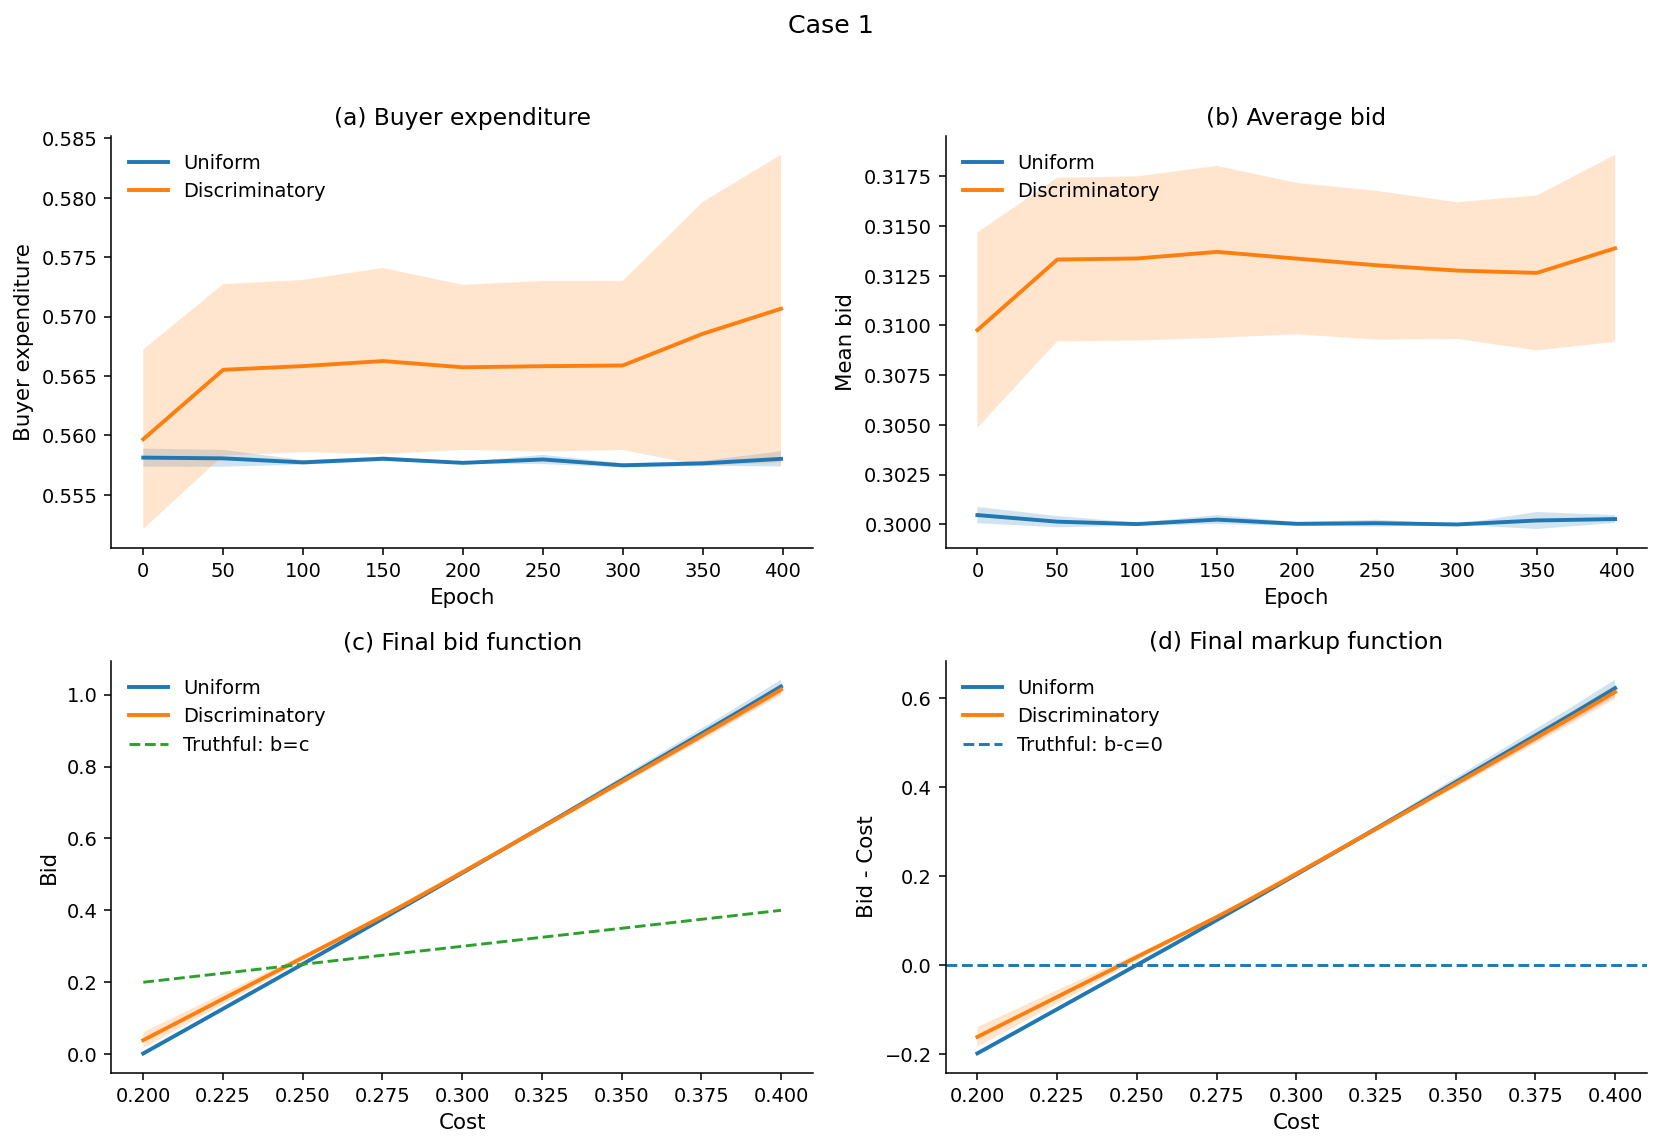

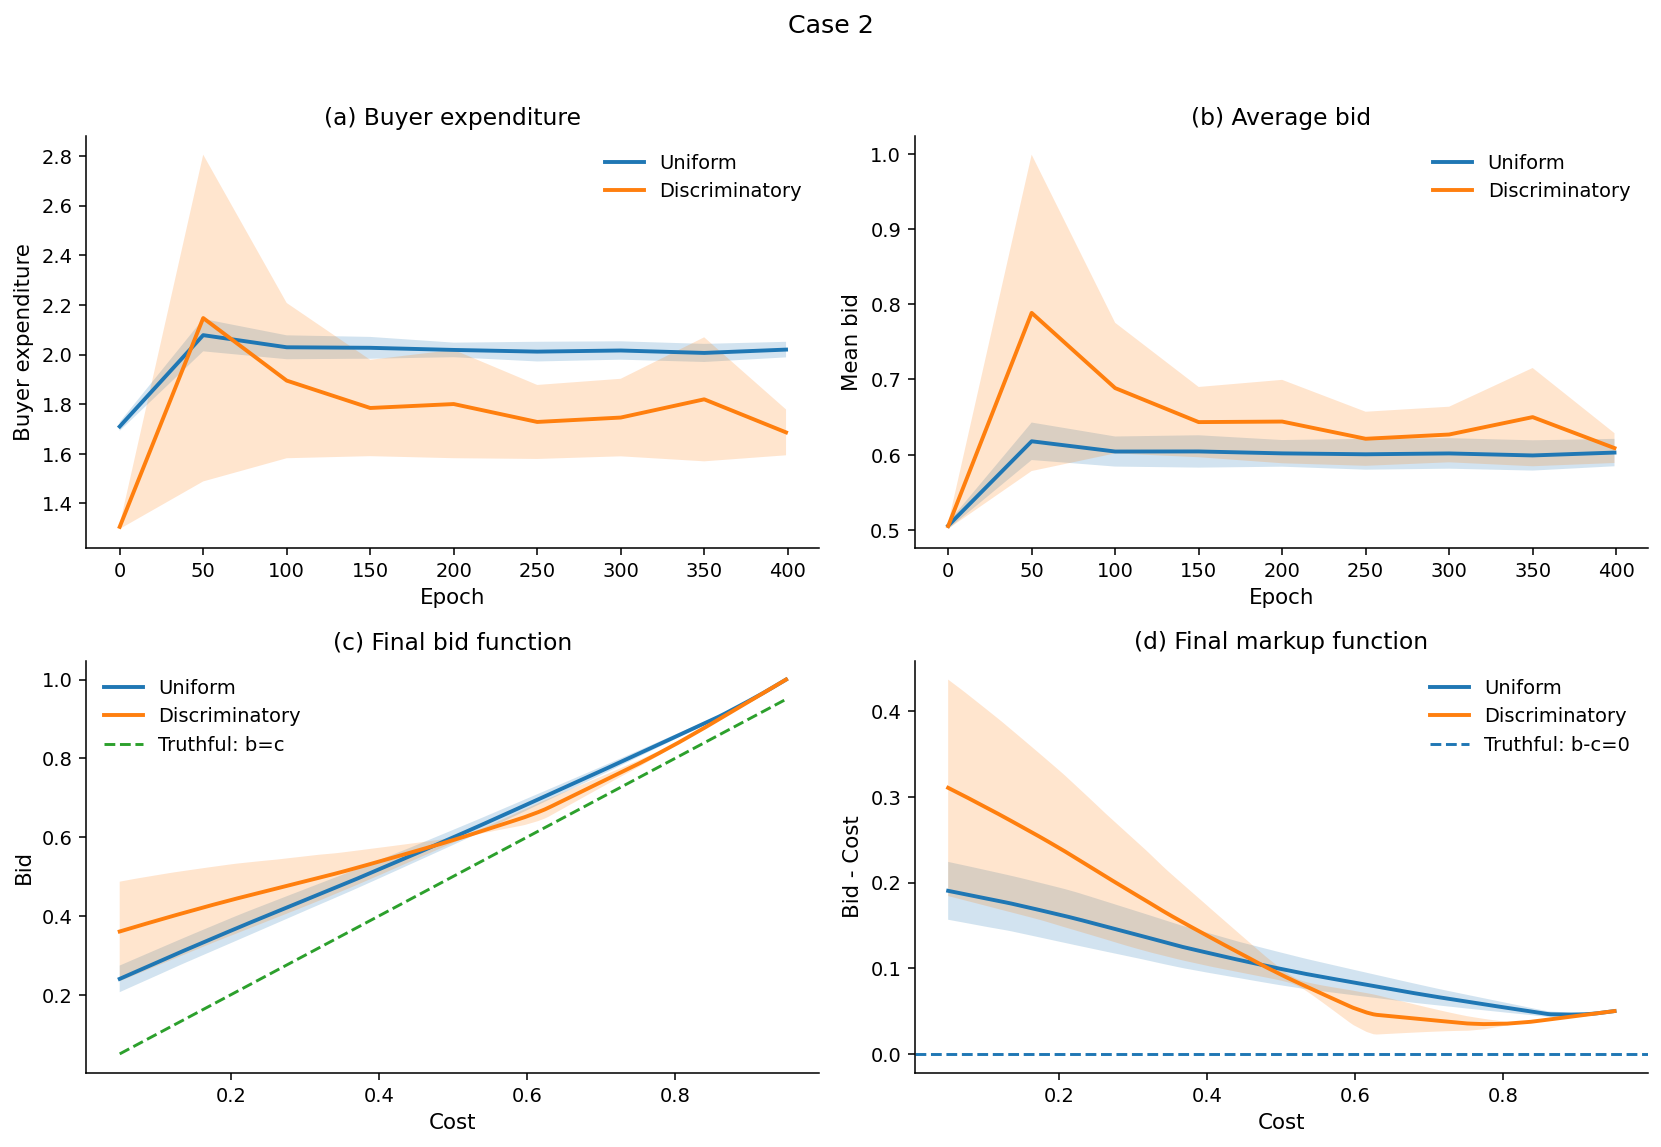

In [24]:
plot_pair_paper(
    results_uniform_case1,
    results_pab_case1,
    title_prefix="Case 1",
    save_dir="simulationPABvsPAC"
)

plot_pair_paper(
    results_uniform_case2,
    results_pab_case2,
    title_prefix="Case 2",
    save_dir="simulationPABvsPAC"
)

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. HELPERS
# ============================================================
def mean_path(results_list, metric):
    arr = np.array([run[metric] for run in results_list], dtype=float)
    return arr.mean(axis=0), arr.std(axis=0)

def final_metric_mean_std(results, metric="buyer_cost"):
    vals = np.array([run[metric][-1] for run in results], dtype=float)
    return vals.mean(), vals.std()

def paper_style():
    plt.rcParams.update({
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
    })


# ============================================================
# 2. MAIN FIGURE FOR PAPER
#    1x2:
#    (a) buyer expenditure
#    (b) average bid
# ============================================================
def plot_pair_paper(
    results_uniform,
    results_pab,
    title_prefix,
    save_dir=None,
    metric_key="buyer_cost",
    metric_label="Buyer expenditure"
):
    paper_style()

    epochs = np.array(results_uniform[0]["epoch"])

    # ---------------- Time-series metrics ----------------
    u_exp_mean, u_exp_std = mean_path(results_uniform, metric_key)
    p_exp_mean, p_exp_std = mean_path(results_pab, metric_key)

    u_bid_mean, u_bid_std = mean_path(results_uniform, "avg_bid")
    p_bid_mean, p_bid_std = mean_path(results_pab, "avg_bid")

    # ---------------- Figure ----------------
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # (a) Buyer expenditure
    ax = axes[0]
    ax.plot(epochs, u_exp_mean, label="Uniform")
    ax.fill_between(
        epochs,
        u_exp_mean - u_exp_std,
        u_exp_mean + u_exp_std,
        alpha=0.2
    )
    ax.plot(epochs, p_exp_mean, label="Discriminatory")
    ax.fill_between(
        epochs,
        p_exp_mean - p_exp_std,
        p_exp_mean + p_exp_std,
        alpha=0.2
    )
    ax.set_title("(a) Buyer expenditure")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric_label)
    ax.legend()

    # (b) Average bid
    ax = axes[1]
    ax.plot(epochs, u_bid_mean, label="Uniform")
    ax.fill_between(
        epochs,
        u_bid_mean - u_bid_std,
        u_bid_mean + u_bid_std,
        alpha=0.2
    )
    ax.plot(epochs, p_bid_mean, label="Discriminatory")
    ax.fill_between(
        epochs,
        p_bid_mean - p_bid_std,
        p_bid_mean + p_bid_std,
        alpha=0.2
    )
    ax.set_title("(b) Average bid")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean bid")
    ax.legend()

    fig.suptitle(title_prefix, y=1.03, fontsize=13)
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        safe_title = title_prefix.lower().replace(" ", "_").replace(":", "")
        fig.savefig(os.path.join(save_dir, f"{safe_title}_two_panels.pdf"), bbox_inches="tight")
        fig.savefig(os.path.join(save_dir, f"{safe_title}_two_panels.png"), bbox_inches="tight")

    plt.show()

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt

def mean_path(results_list, metric):
    arr = np.array([run[metric] for run in results_list], dtype=float)
    return arr.mean(axis=0), arr.std(axis=0)

def final_metric_mean_std(results, metric="buyer_cost"):
    vals = np.array([run[metric][-1] for run in results], dtype=float)
    return vals.mean(), vals.std()

def paper_style():
    plt.rcParams.update({
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
    })


# ============================================================
# 2. MAIN FIGURE FOR PAPER
#    1x2:
#    (a) buyer expenditure
#    (b) average bid
# ============================================================
def plot_pair_paper(
    results_uniform,
    results_pab,
    title_prefix,
    save_dir=None,
    metric_key="buyer_cost",
    metric_label="Buyer expenditure"
):
    paper_style()

    uniform_color = "skyblue"
    pab_color = "darkred"

    epochs = np.array(results_uniform[0]["epoch"])

    # ---------------- Time-series metrics ----------------
    u_exp_mean, u_exp_std = mean_path(results_uniform, metric_key)
    p_exp_mean, p_exp_std = mean_path(results_pab, metric_key)

    u_bid_mean, u_bid_std = mean_path(results_uniform, "avg_bid")
    p_bid_mean, p_bid_std = mean_path(results_pab, "avg_bid")

    # ---------------- Figure ----------------
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # (a) Buyer expenditure
    ax = axes[0]
    ax.plot(epochs, u_exp_mean, label="Uniform", color=uniform_color)
    ax.fill_between(
        epochs,
        u_exp_mean - u_exp_std,
        u_exp_mean + u_exp_std,
        alpha=0.20,
        color=uniform_color
    )
    ax.plot(epochs, p_exp_mean, label="Discriminatory", color=pab_color)
    ax.fill_between(
        epochs,
        p_exp_mean - p_exp_std,
        p_exp_mean + p_exp_std,
        alpha=0.20,
        color=pab_color
    )
    ax.set_title("(a) Buyer expenditure")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric_label)
    ax.legend()

    # (b) Average bid
    ax = axes[1]
    ax.plot(epochs, u_bid_mean, label="Uniform", color=uniform_color)
    ax.fill_between(
        epochs,
        u_bid_mean - u_bid_std,
        u_bid_mean + u_bid_std,
        alpha=0.20,
        color=uniform_color
    )
    ax.plot(epochs, p_bid_mean, label="Discriminatory", color=pab_color)
    ax.fill_between(
        epochs,
        p_bid_mean - p_bid_std,
        p_bid_mean + p_bid_std,
        alpha=0.20,
        color=pab_color
    )
    ax.set_title("(b) Average bid")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean bid")
    ax.legend()

    fig.suptitle(title_prefix, y=1.03, fontsize=13)
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        safe_title = title_prefix.lower().replace(" ", "_").replace(":", "")
        fig.savefig(os.path.join(save_dir, f"{safe_title}_two_panels.pdf"), bbox_inches="tight")
        fig.savefig(os.path.join(save_dir, f"{safe_title}_two_panels.png"), bbox_inches="tight")

    plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def mean_path(results_list, metric):
    arr = np.array([run[metric] for run in results_list], dtype=float)
    return arr.mean(axis=0), arr.std(axis=0)

def final_metric_mean_std(results, metric="buyer_cost"):
    vals = np.array([run[metric][-1] for run in results], dtype=float)
    return vals.mean(), vals.std()

def paper_style():
    plt.rcParams.update({
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
    })


# ============================================================
# 2. MAIN FIGURE FOR PAPER
#    1x2:
#    (a) buyer expenditure
#    (b) average bid
# ============================================================
def plot_pair_paper(
    results_uniform,
    results_pab,
    title_prefix,
    save_dir=None,
    metric_key="buyer_cost",
    metric_label="Auctioneer’s expenditure"
):
    paper_style()

    uniform_color = "skyblue"
    pab_color = "darkred"

    epochs = np.array(results_uniform[0]["epoch"])

    # ---------------- Time-series metrics ----------------
    u_exp_mean, u_exp_std = mean_path(results_uniform, metric_key)
    p_exp_mean, p_exp_std = mean_path(results_pab, metric_key)

    u_bid_mean, u_bid_std = mean_path(results_uniform, "avg_bid")
    p_bid_mean, p_bid_std = mean_path(results_pab, "avg_bid")

    # ---------------- Figure ----------------
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # (a) Buyer expenditure
    ax = axes[0]
    ax.plot(epochs, u_exp_mean, label="Uniform", color=uniform_color)
    ax.fill_between(
        epochs,
        u_exp_mean - u_exp_std,
        u_exp_mean + u_exp_std,
        alpha=0.20,
        color=uniform_color
    )
    ax.plot(epochs, p_exp_mean, label="Discriminatory", color=pab_color)
    ax.fill_between(
        epochs,
        p_exp_mean - p_exp_std,
        p_exp_mean + p_exp_std,
        alpha=0.20,
        color=pab_color
    )
    ax.set_title("(a) Auctioneer’s expenditure")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric_label)
    ax.legend()

    # (b) Average bid
    ax = axes[1]
    ax.plot(epochs, u_bid_mean, label="Uniform", color=uniform_color)
    ax.fill_between(
        epochs,
        u_bid_mean - u_bid_std,
        u_bid_mean + u_bid_std,
        alpha=0.20,
        color=uniform_color
    )
    ax.plot(epochs, p_bid_mean, label="Discriminatory", color=pab_color)
    ax.fill_between(
        epochs,
        p_bid_mean - p_bid_std,
        p_bid_mean + p_bid_std,
        alpha=0.20,
        color=pab_color
    )
    ax.set_title("(b) Average bid")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean bid")
    ax.legend()

    fig.suptitle(title_prefix, y=1.03, fontsize=13)
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        safe_title = title_prefix.lower().replace(" ", "_").replace(":", "")
        fig.savefig(os.path.join(save_dir, f"{safe_title}_two_panels.pdf"), bbox_inches="tight")
        fig.savefig(os.path.join(save_dir, f"{safe_title}_two_panels.png"), bbox_inches="tight")

    plt.show()

In [1]:
plot_pair_paper(
    results_uniform_case1,
    results_pab_case1,
    title_prefix="A simulated scenario where uniform pricing reduces the auctioneer’s expenditures",
    save_dir="simulationPABvsPAC"
)

plot_pair_paper(
    results_uniform_case2,
    results_pab_case2,
    title_prefix=" simulated scenario where discriminatory pricing reduces the auctioneer’s expenditures",
    save_dir="simulationPABvsPAC"
)

NameError: name 'plot_pair_paper' is not defined